In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Libraries

• Imported pandas and numpy for data manipulation and analysis  
• Imported matplotlib and seaborn for data visualization  

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Data Loading and Preview

• Loaded the Titanic dataset using pandas  
• Displayed the first few rows to understand the structure of the dataset  
• Observed columns like PassengerId, Survived, Pclass, Sex, Age, Fare, etc.  

In [ ]:
X = df[["Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]]
y = df["Survived"]

### Feature Selection and Target Variable

• Selected important features such as Pclass, Sex, Age, SibSp, Parch, Fare, and Embarked  
• Defined the target variable as 'Survived'  
• Split the dataset into input features (X) and target variable (y)  

In [ ]:
from sklearn.impute import SimpleImputer

num_cols = ["Age","Fare"]
cat_cols = ["Sex","Embarked","Pclass"]

### Identifying Numerical and Categorical Columns

• Identified numerical columns: Age and Fare  
• Identified categorical columns: Sex, Embarked, and Pclass  
• This separation helps in applying different preprocessing techniques  

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

### Importing Preprocessing Tools

• Imported SimpleImputer to handle missing values  
• Used StandardScaler for scaling numerical features  
• Used OneHotEncoder for encoding categorical variables  
• Used ColumnTransformer and Pipeline to combine preprocessing steps  

In [ ]:
from sklearn.impute import SimpleImputer
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

### Data Preprocessing using Pipelines

• Created a numerical pipeline using SimpleImputer with median strategy to handle missing values in Age and Fare  
• Applied StandardScaler to normalize numerical features  

• Created a categorical pipeline using SimpleImputer with most frequent strategy to handle missing values in Sex, Embarked, and Pclass  
• Applied OneHotEncoder to convert categorical variables into numerical format  

• Combined both numerical and categorical pipelines using ColumnTransformer  
• This ensures all preprocessing steps are applied consistently to the dataset before feeding into the model  

In [ ]:
from sklearn.linear_model import LogisticRegression
model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

### Model Building

• Built a machine learning pipeline combining preprocessing and classification  
• Used Logistic Regression as the classification algorithm  
• Set max_iter=1000 to ensure proper convergence of the model  
• This pipeline automates preprocessing and model training in a single workflow  

In [ ]:
from sklearn.model_selection import train_test_split
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Splitting Data into Training and Testing Sets

• Selected input features (X) and target variable (y) for model training  
• Split the dataset into training and testing sets using train_test_split  

• Used 80% of the data for training and 20% for testing  
• Applied stratified sampling to maintain the proportion of the target variable (Survived)  
• Set random_state=42 to ensure reproducibility of results  

In [ ]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### Numerical Feature Processing

• Created a pipeline for numerical features (Age and Fare)  
• Used median imputation to handle missing values  
• Applied standard scaling to normalize the data  
• This helps improve performance of the Logistic Regression model  

In [ ]:
from sklearn.model_selection import train_test_split
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Data Splitting

• Selected features and target variable (Survived)  
• Split dataset into training (80%) and testing (20%) sets  
• Used stratified sampling to maintain class balance  
• Ensured reproducibility using random_state=42  

In [ ]:
from sklearn.linear_model import LogisticRegression
model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

### Model Building

• Built a machine learning pipeline combining preprocessing and classification  
• Used Logistic Regression as the model  
• Set max_iter=1000 to ensure proper convergence  
• This pipeline automates preprocessing and model training  

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'Pclass'])])),
                ('clf', LogisticRegression(max_iter=1000))])

### Model Training

• Trained the machine learning pipeline on the training dataset  
• Preprocessing steps were automatically applied before training  
• Logistic Regression model learned patterns from the data  

In [ ]:
y_pred = model.predict(X_test)

### Model Prediction

• Used the trained model to make predictions on the test dataset  
• Generated predicted values for the target variable (Survived)  

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       110
           1       0.72      0.67      0.69        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179



### Classification Report

• Evaluated the model using precision, recall, and F1-score  
• Class 0 (non-survived) has better performance compared to Class 1 (survived)  
• Overall model accuracy is around 77%  
• Macro and weighted averages indicate balanced performance across classes  

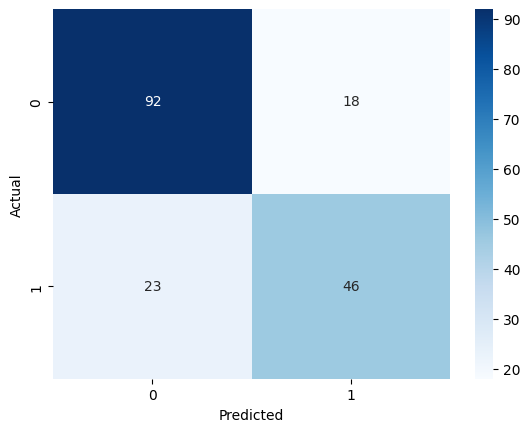

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix

• Visualized model performance using confusion matrix  
• Model correctly predicted 92 non-survivors and 46 survivors  
• Some misclassifications observed (18 false positives, 23 false negatives)  
• Model performs better on non-survivors compared to survivors  

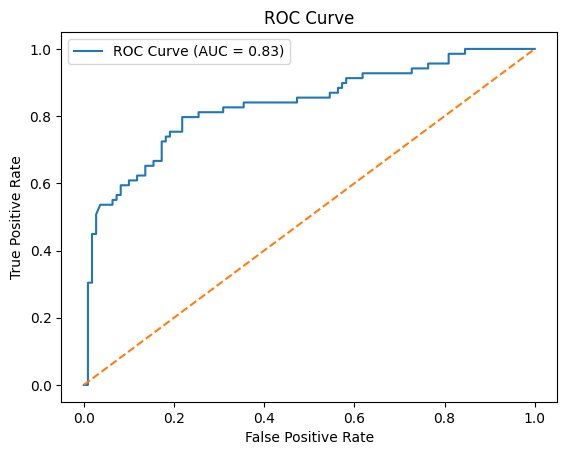

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label="ROC Curve (AUC = " + str(round(auc,2)) + ")")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### ROC Curve and AUC Score

• Plotted the ROC Curve to evaluate model performance  
• The curve shows the trade-off between True Positive Rate and False Positive Rate  
• Calculated AUC score to measure the model’s ability to distinguish between classes  
• AUC value close to 1 indicates good model performance  

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="roc_auc")

print("ROC-AUC scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

ROC-AUC scores: [0.83306983 0.83502674 0.84926471 0.84278075 0.86743784]
Mean: 0.8455159723896084
Std: 0.01238574417106465


### Cross Validation

• Performed 5-fold cross-validation using ROC-AUC as the evaluation metric  
• Model was trained and validated on different splits of the dataset  
• Mean ROC-AUC score indicates overall model performance  
• Low standard deviation shows that the model is stable and consistent  

In [ ]:
import joblib

joblib.dump(model, "model.joblib")

['model.joblib']

### Model Saving

• Saved the trained machine learning pipeline using joblib  
• This allows the model to be reused without retraining  
• The model is stored as a file named 'model.joblib'  

In [29]:
loaded_model = joblib.load("model.joblib")

### Model Loading

• Loaded the saved model from the file 'model.joblib'  
• This enables reuse of the trained model for future predictions  

In [ ]:
loaded_model.predict(X_test[:5])

array([0, 0, 0, 0, 1])

### Prediction using Loaded Model

• Used the loaded model to make predictions on sample test data  
• Demonstrates that the saved model works correctly after loading  

### Documentation

• Selected important features such as Pclass, Sex, Age, Fare, etc.  
• Handled missing values using median (numeric) and most frequent (categorical)  
• Applied one-hot encoding for categorical variables  
• Standardized numerical features for better model performance  
• Built a pipeline combining preprocessing and Logistic Regression  
• Evaluated using classification report, confusion matrix, and ROC-AUC  

### Key Takeaways

• Passenger class (Pclass) plays an important role in survival prediction  
• Gender (Sex) is a strong factor, with females having higher survival rates  
• Age and Fare also contribute to the model’s predictions  
• Logistic Regression provides a simple and interpretable baseline model  
• Model achieved around 77% accuracy on the test dataset  
• ROC-AUC score (~0.84) indicates good classification performance  
• The model performs better for non-survivors than survivors  
• Cross-validation shows the model is stable and consistent  
• One limitation is that the model may not capture complex patterns  
• Future improvements can include advanced models like Random Forest or XGBoost  